# Disk Modeling Basics

## Introduction

This notebook provides an introduction to the **disk modeling workflow** in `grater-jax`.  
It shows how the framework builds scattered-light debris disk images from modular components that represent different physical and instrumental effects.

The model is structured into the following pieces:

- **Dust Distribution** – specifies the 3D density of dust grains (e.g., radial power-law slopes, eccentricity, vertical scale height).  
- **Scattering Phase Function (SPF)** – controls how starlight is scattered by dust as a function of angle (Henyey–Greenstein, double HG, or spline-based models).  
- **Point Spread Function (PSF)** – applies instrument response by convolving the model image with a chosen PSF kernel (Gaussian, empirical, etc.).  

The notebook demonstrates how to configure these components, run them through the `objective_model` pipeline, and generate synthetic disk images that can be compared directly with observations. Additional information on the analytic model definition is also provided here.


#### Defining the Dust Distribution

GRaTeR-JAX follows the same dust distribution parameterization as the disk forward modeling module in [VIP](https://vip.readthedocs.io/en/latest/tutorials/05B_fm_disks.html), which is also based off the framework introduced in Augereau+ 1999. The density distribution is in cylindrical coordinates, and contains three major terms: the surface density at the reference radius of the dust in the midplane ($z$=0) $\rho_0$, the density distribution in the midplane, and the vertical profile, as shown below:

$$\rho(r,\theta,z) = \rho_0 \times \left( \frac{2}{\left(\frac{r}{R(\theta)}\right)^{-2\alpha_{\rm in}}\left(\frac{r}{R(\theta)}\right)^{2\alpha_{\rm out}}}\right)^{1/2} \times e^{-\left(\frac{z}{H(r)}\right)^\gamma}$$

where:
- $\alpha_{\rm in}$ and $\alpha_{\rm out}$ are the inner and outer power laws describing the radial dust distribution
- $R(\theta)$ is the reference radius
- $a$ is the semimajor axis
- $e$ is the eccentricity
- $\gamma$ is the decay exponent ($\gamma$=2 corresponds to a Gaussian profile)
- $H(r)$ is the scale height defined as follows (where $\xi_0$ is the scale height at the reference radius and $\beta$ is the flaring coefficient (with $\beta$=1 corresponding to linear flaring)):

\begin{equation}
    H(r) = \xi_0 \times \left(\frac{r}{R(\theta)}\right)^\beta
\end{equation}

Note that the reference radius is dependent on $\theta$ for an elliptical disk, as $R(\theta) = \frac{a(1-e^2)}{1+e{\rm cos}(\theta)}$.

#### Scattering Phase Functions

The scattering phase function (SPF) describes the amount of light scattered by a particle (e.g. a dust grain) at different scattering angles $\theta_{\rm sca}$, which ranges from 0 (forward scattering) to 180 (back scattering). Debris disks generally have more forward scattering phase functions. 

The range of scattering angles probed in any given observation is limited by viewing geometry, and that limit is incorporated into GRaTeR-JAX by using an initial guess of inclination to bound the scattering angles used in the model's SPF with the relationships $\theta_{\rm sca,min}\approx90-i$ and $\theta_{\rm sca,max}\approx90+i$.

GRaTeR-JAX provides three options for the SPF:

1. Henyey-Greenstein: an analytical function determined by the scattering angle $\theta_{\rm sca}$ and the asymmetry parameter $g$, where isotropic scattering is indicated with $g$=0, forward scattering with 0$\leq g \leq$1, and back scattering with -1$\geq g \geq$0 [(Henyey and Greenstein 1941)](https://ui.adsabs.harvard.edu/abs/1941ApJ....93...70H/abstract)
\begin{equation}
    I(\theta_{\rm sca}) = \frac{1}{4\pi} \frac{1-g^2}{[1+g^2-2g {\rm cos}\theta_{\rm sca}]^{3/2}}
\end{equation}
2. Double Henyey-Greenstein: a weighted combination of two HG functions, where the free parameters are the first asymmetry parameter $g_1$, the second function's asymmetry parameter, $g_2$, and the relative weight of the two
3. Spline: a more flexible framework ***not*** based on an analytic function; here, a specified number of knots are fit at scattering angles between bounds defined by the approximate inclination of the disk. The number of knots $n_k$ is determined by the user. The absolute values of the spline knots are degenerate with the overall flux scaling of the disk; as a result, the SPF is normalized such that it is equal to 1 at 90 deg and the flux scaling factor is adjusted accordingly. See the spline injection and recovery tutorial notebook for more information on the assumptions in this formalism.

### Setup

First, import the relevant components of GRaTer-JAX and outside packages. The two environment variables set are related to JAX's handling of memory allocation, and reduce memory usage errors.

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.15"

from grater_jax.disk_model.objective_functions import objective_model, objective_fit, log_likelihood, Parameter_Index
from grater_jax.disk_model.SLD_utils import DoubleHenyeyGreenstein_SPF, InterpolatedUnivariateSpline_SPF, EMP_PSF, DustEllipticalDistribution2PowerLaws, Winnie_PSF
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_debug_nans", True) <-- can use this to trace issues at the cost of runtime

## Generating Disk Models with Simple PSFs

### Empirical PSF Image

This example notebook uses an empirically-measured PSF from Gemini Planet Imager H-band data ([Macintosh+ 2014](https://ui.adsabs.harvard.edu/abs/2014SPIE.9148E..0JM/abstract), [Crotts+ 2025](https://iopscience.iop.org/article/10.3847/1538-4365/ad90a4/pdf)). More complex PSFs, such as those from JWST, are explored in the JWST Tutorial (Experimental).

In [2]:
# Generates a simple psf function image
scale_factor = 1
image = fits.open("tutorial_images/GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

### Simple Disk Model

Here, we generate a simple disk model with specified parameters. There are four dictionaries: disk_params, spf_params, psf_params, and misc_params. These contain the following parameters relevant to a user:

**Disk Parameters (`disk_params`):**
- $\alpha_{\rm in}$ (keyword: `alpha_in`)
- $\alpha_{\rm out}$ (`alpha_out`)
- semimajor axis (`sma`)
- eccentricity $e$ (`e`)
- $xi_0$ (`ksi0`)
- $\gamma$ (`gamma`)
- $\beta$ (`beta`)
- $i$ (`inclination`)
- PA (`position_angle`)
- $x_c$ (`x_center`)
- $y_c$ (`y_center`)
- $\omega$ (`omega`)

**SPF Parameters (`spf_params`):**

If Single HG (`HenyeyGreenstein_SPF`):
- asymmetry parameter $g$ (`g`)

If Double HG (`DoubleHenyeyGreenstein_SPF`):
- first asymmetry parameter $g_1$ (`g1`)
- second asymmetry parameter $g_2$ (`g2`)
- relative weight (`weight`)

If Spline (`InterpolatedUnivariateSpline_SPF`):
- number of knots $n_k$ (`num_knots`)
- array of knot $y$ values (`knot_values`)
- back scattering bound — cosine of angle in radians, defaults to -1 (equivalent to 180 deg), but can be set by inclination (`backscatt_bound`)
- forward scattering bound — cosine of angle in radians, defaults to 1 (equivalent to 0 deg), but can be set by inclination (`forwardscatt_bound`)

**Miscellaneous Parameters (`misc_params`):**
- distance to target (`distance`)
- pixel scale in arcsec/pix (`pxInArcsec`)
- number of pixels in x dimension (`nx`)
- number of pixels in y dimension (`ny`)
- number of slices calculated in the model (increase if you are encountering computational artifacts, but increasing also lengthens runtime) (`halfNbSlices`) 
- arbitrary flux scaling (`flux_scaling`)

In [3]:
EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
spf_params = DoubleHenyeyGreenstein_SPF.params
psf_params = EMP_PSF.params

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
disk_params['sma'] = 40
disk_params['inclination'] = 60
disk_params['position_angle'] = 30

# Initializing the misc parameter dictionary
misc_params = Parameter_Index.misc_params

# Setting flux_scaling to custom value
misc_params['flux_scaling'] = 1e4

simple_disk_img = objective_model(disk_params, spf_params, psf_params, misc_params,
                        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, DoubleHenyeyGreenstein_SPF, EMP_PSF)

#### Disk Model Image

Text(0.5, 1.0, 'Simple Scattered Light Disk Model')

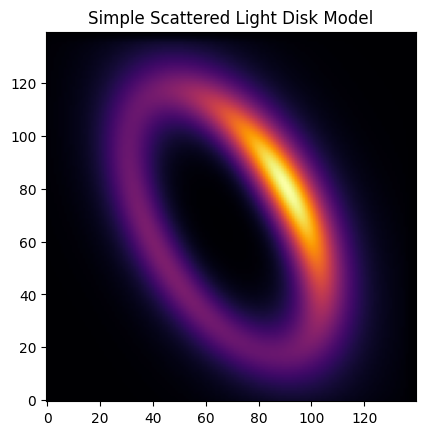

In [4]:
plt.imshow(simple_disk_img, origin='lower', cmap='inferno')
plt.title('Simple Scattered Light Disk Model')

#### Runtime Analysis

In [5]:
%timeit objective_model(disk_params, spf_params, psf_params, Parameter_Index.misc_params, ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, DoubleHenyeyGreenstein_SPF, EMP_PSF)

2.28 ms ± 10.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Forward Modeling

#### Generating a Target Disk

To illustrate GRaTer-JAX's ability to model a disk accurately, we will use the image generated above as our ``data" by adding noise to it.

Text(0.5, 1.0, 'Target Disk')

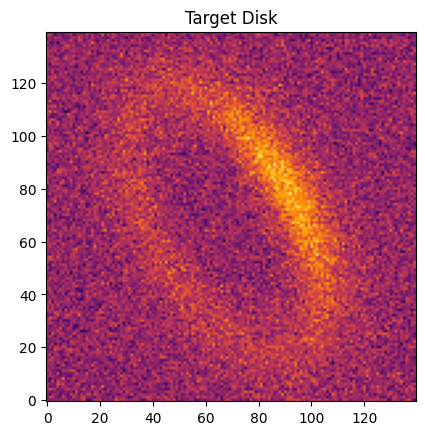

In [6]:
noise_level = 1
noise = np.random.normal(0, noise_level, simple_disk_img.shape)
target_image = simple_disk_img + noise
err_map = jnp.ones(simple_disk_img.shape)*noise_level
plt.imshow(target_image, origin='lower', cmap='inferno')
plt.title('Target Disk')

### Getting the Log-Likelihood

Now that we have our target image set up, we can set up the infrastructure for the fit using `objective_model` and some starting guess parameters.

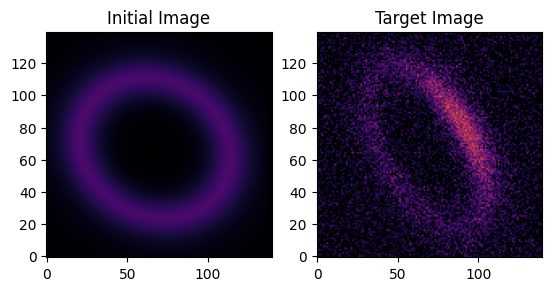

Log-Likelihood: -0.8493804205797295


In [7]:
EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
start_spf_params = InterpolatedUnivariateSpline_SPF.params
start_psf_params = EMP_PSF.params

# Initializing spline spf parameters
start_spf_params['num_knots'] = 5
start_spf_params['knot_values'] = jnp.ones(5)*0.1
start_spf_params['backscatt_bound'] = -0.9
start_spf_params['frontscatt_bound'] = 0.9

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
start_disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
start_disk_params['sma'] = 35
start_disk_params['inclination'] = 30
start_disk_params['position_angle'] = 60

misc_params = Parameter_Index.misc_params
misc_params['flux_scaling'] = 1e4

start_image = objective_model(start_disk_params, start_spf_params, start_psf_params, Parameter_Index.misc_params,
                        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, EMP_PSF)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(start_image, origin='lower', cmap='inferno', vmin=0, vmax=10)
axes[0].set_title('Initial Image')
axes[1].imshow(target_image, origin='lower', cmap='inferno', vmin=0, vmax=10)
axes[1].set_title('Target Image')
plt.show()

print(f'Log-Likelihood: {log_likelihood(start_image, target_image, err_map)}')

### Disk Fitting using Scipy Optimize Minimize

Here we perform a simple fit using `scipy.minimize` --- more complex parameter estimation is possible with MCMC, which is illustrated in the advanced disk modeling tutorial.

In [8]:
from scipy.optimize import minimize

# Specifying parameters to be fit
fit_keys = ['sma', 'inclination', 'position_angle', 'knot_values']

# Creating objective function
llp = lambda x: -objective_fit([x[0], x[1], x[2], x[3:]], fit_keys, start_disk_params, start_spf_params, start_psf_params,
                               Parameter_Index.misc_params, ScatteredLightDisk, DustEllipticalDistribution2PowerLaws,
                               InterpolatedUnivariateSpline_SPF, EMP_PSF, target_image, err_map)

# Initial Parameters (need to be in array form)
init_x = jnp.concatenate([jnp.array([start_disk_params['sma'], start_disk_params['inclination'], start_disk_params['position_angle']]), start_spf_params['knot_values']])

soln = minimize(llp, init_x, method='Nelder-Mead', options={'disp': True, 'maxiter': 500})


print(soln)

       message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: 0.4990589908936718
             x: [ 4.003e+01  6.011e+01  2.816e+01  2.678e-01  7.398e-02
                  6.238e-02  4.216e-02  6.942e-02]
           nit: 500
          nfev: 714
 final_simplex: (array([[ 4.003e+01,  6.011e+01, ...,  4.216e-02,
                         6.942e-02],
                       [ 4.054e+01,  6.043e+01, ...,  3.578e-02,
                         7.303e-02],
                       ...,
                       [ 4.035e+01,  6.060e+01, ...,  3.880e-02,
                         7.131e-02],
                       [ 4.006e+01,  5.983e+01, ...,  3.915e-02,
                         7.130e-02]], shape=(9, 8)), array([ 4.991e-01,  5.001e-01,  5.003e-01,  5.004e-01,
                        5.004e-01,  5.006e-01,  5.007e-01,  5.007e-01,
                        5.011e-01]))


/tmp/ipykernel_3911663/1663551463.py:14: RuntimeWarning: Maximum number of iterations has been exceeded.
  soln = minimize(llp, init_x, method='Nelder-Mead', options={'disp': True, 'maxiter': 500})


#### Numeric Results

In [9]:
print(f"Disk Fit Log Likelihood: {-soln.fun}")

Disk Fit Log Likelihood: -0.4990589908936718


#### Visual Results

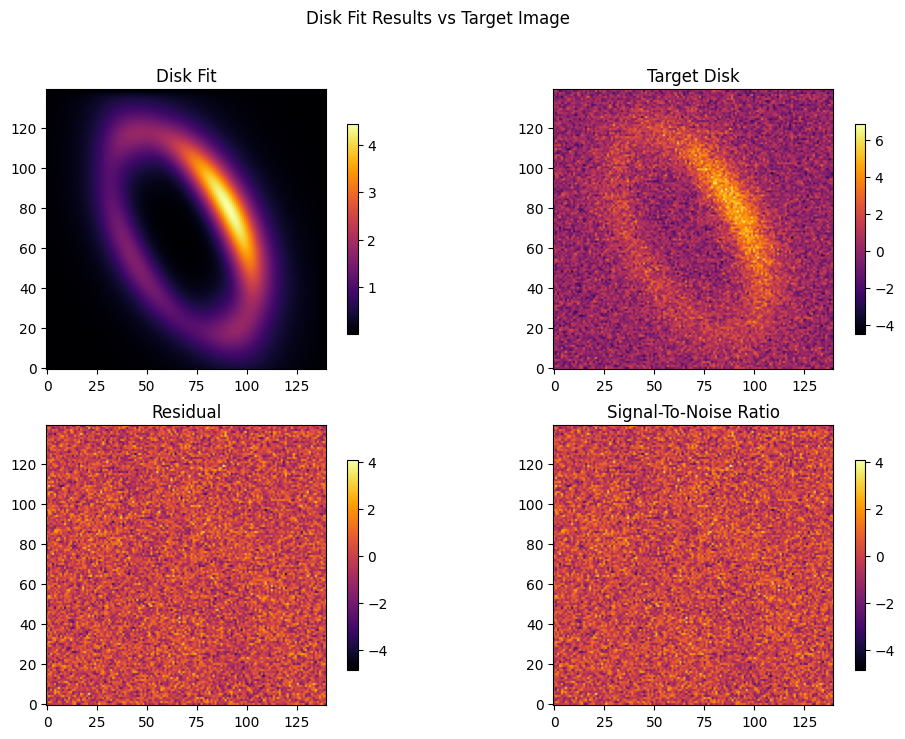

In [10]:
new_disk_params = disk_params.copy()
new_spf_params = start_spf_params.copy()
new_disk_params['sma'] = soln.x[0]
new_disk_params['inclination'] = soln.x[1]
new_disk_params['position_angle'] = soln.x[2]
new_spf_params['knot_values'] = soln.x[3:]

fitted_image = objective_model(new_disk_params, new_spf_params, psf_params, Parameter_Index.misc_params, ScatteredLightDisk, DustEllipticalDistribution2PowerLaws,
                                InterpolatedUnivariateSpline_SPF, EMP_PSF)

fig, axes = plt.subplots(2, 2, figsize=(12,8))

fitted_pic = axes[0][0].imshow(fitted_image, origin='lower', cmap='inferno')
axes[0][0].set_title('Disk Fit')
plt.colorbar(fitted_pic, ax=axes[0][0], shrink=0.75)

target_pic = axes[0][1].imshow(target_image, origin='lower', cmap='inferno')
axes[0][1].set_title('Target Disk')
plt.colorbar(target_pic, ax=axes[0][1], shrink=0.75)

residual_pic = axes[1][0].imshow(target_image-fitted_image, origin='lower', cmap='inferno')
axes[1][0].set_title('Residual')
plt.colorbar(residual_pic, ax=axes[1][0], shrink=0.75)

residual_pic = axes[1][1].imshow(np.where(err_map == 0, 0., (target_image-fitted_image)/err_map), origin='lower', cmap='inferno')
axes[1][1].set_title('Signal-To-Noise Ratio')
plt.colorbar(residual_pic, ax=axes[1][1], shrink=0.75)

fig.suptitle("Disk Fit Results vs Target Image")
plt.show()

As you can see, even with a relatively simple fitting routine, GRaTer-JAX is able to produce a model that visually matches the target quite well. Although the target disk was generated with a Double Henyey-Greenstein SPF, we perform the fit using the flexible spline framework. The plot below illustrates how the spline is able to recover the input SPF.

#### Spline Fit Results

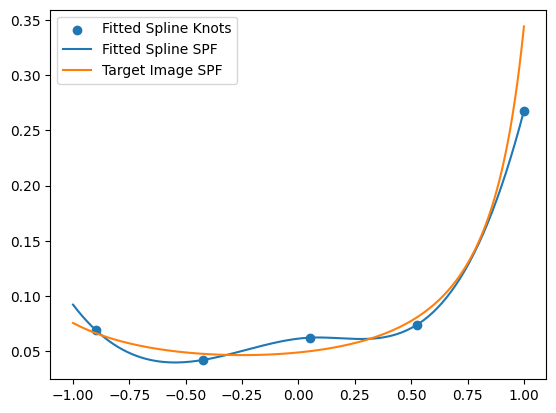

In [11]:
x_vals = jnp.linspace(-1, 1, 200)
knot_locs = InterpolatedUnivariateSpline_SPF.get_knots(new_spf_params)
plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(new_spf_params['knot_values'],
                    knots=knot_locs)(knot_locs))
plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(new_spf_params['knot_values'],
                    knots=knot_locs)(x_vals))
plt.plot(x_vals, DoubleHenyeyGreenstein_SPF.compute_phase_function_from_cosphi(DoubleHenyeyGreenstein_SPF.pack_pars(spf_params), x_vals))

plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])

## Takeaways

As you can see, the objective functions provide a useful utility for fitting disks with great accuracy. However, for more complicated models, the process for fitting a disk with just the objective function is very cumbersome and not as precise. If you want a simpler way to work with more complex disks, leverage autodifferentiation, and run comprehensive sampling algorithms, refer to the Advanced Disk Modeling tutorial where we demonstrate the Optimizer class.